<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Polarizaci%C3%B3n_Argentina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!wget https://www.argentina.gob.ar/sites/default/files/2023_generales_1.zip
!unzip 2023_generales_1.zip

--2026-03-26 17:38:21--  https://www.argentina.gob.ar/sites/default/files/2023_generales_1.zip
Resolving www.argentina.gob.ar (www.argentina.gob.ar)... 104.26.4.183, 172.67.75.35, 104.26.5.183, ...
Connecting to www.argentina.gob.ar (www.argentina.gob.ar)|104.26.4.183|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28028857 (27M) [application/zip]
Saving to: ‘2023_generales_1.zip.2’

2023_generales_1.zi 100%[===================>]  26.73M   125MB/s    in 0.2s    

2026-03-26 17:38:21 (125 MB/s) - ‘2023_generales_1.zip.2’ saved [28028857/28028857]

Archive:  2023_generales_1.zip
replace 2023_Generales/AmbitosElectorales_2023_Generales.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: 2023_Generales/AmbitosElectorales_2023_Generales.csv  
  inflating: 2023_Generales/Colores_2023.csv  
  inflating: 2023_Generales/ResultadoElectorales_2023_Generales.csv  A
A
A



In [29]:
import pandas as pd

df=pd.read_csv('2023_Generales/ResultadoElectorales_2023_Generales.csv')

/tmp/ipykernel_371/1821905410.py:3: DtypeWarning: Columns (9,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('2023_Generales/ResultadoElectorales_2023_Generales.csv')


In [30]:
df.columns

Index(['año', 'eleccion_tipo', 'eleccion_id', 'recuento_tipo', 'recuento_id',
       'padron_tipo', 'distrito_id', 'distrito_nombre', 'seccionprovincial_id',
       'seccionprovincial_nombre', 'seccion_id', 'seccion_nombre',
       'circuito_id', 'circuito_nombre', 'mesa_id', 'mesa_tipo',
       'mesa_electores', 'cargo_id', 'cargo_nombre', 'agrupacion_id',
       'agrupacion_nombre', 'lista_numero', 'lista_nombre', 'votos_tipo',
       'votos_cantidad'],
      dtype='object')

In [31]:
df['seccion_nombre'].unique()

array(['Comuna 01', 'Comuna 02', 'Comuna 03', 'Comuna 04', 'Comuna 05',
       'Comuna 06', 'Comuna 07', 'Comuna 08', 'Comuna 09', 'Comuna 10',
       'Comuna 11', 'Comuna 12', 'Comuna 13', 'Comuna 14', 'Comuna 15',
       'Adolfo Alsina', 'Alberti', 'Almirante Brown', 'Avellaneda',
       'Ayacucho', 'Azul', 'Bahía Blanca', 'Balcarce', 'Baradero',
       'Arrecifes', 'Berazategui', 'Berisso', 'Bolívar', 'Bragado',
       'Brandsen', 'Campana', 'Cañuelas', 'Capitán Sarmiento',
       'Carlos Casares', 'Carlos Tejedor', 'Carmen de Areco', 'Patagones',
       'Castelli', 'Colón', 'Coronel Dorrego', 'Coronel Pringles',
       'Coronel de Marina L. Rosales', 'Coronel Suárez', 'Chacabuco',
       'Chascomús', 'Chivilcoy', 'Daireaux', 'Dolores', 'Ensenada',
       'Escobar', 'Esteban Echeverría', 'Exaltación de la Cruz',
       'Florencio Varela', 'General Alvarado', 'General Alvear',
       'General Arenales', 'General Belgrano', 'General Guido',
       'General La Madrid', 'General Las Her

In [32]:
from pandas.io.stata import StataReader

with StataReader("https://github.com/LCaravaggio/Happiness_Polarization/raw/refs/heads/main/Latinobarometro_2024_Stata_esp_v20250817.dta") as reader:
    df2 = reader.read(convert_categoricals=False)
    labels = reader.value_labels()

In [33]:
# 1. Filtrar ciudades del país 32
ciudades_codigos = df2.loc[df2['IDENPA'] == 32, 'CIUDAD'].unique()

# 2. Obtener diccionario de labels de CIUDAD
labels_ciudad = labels['CIUDAD']

# 3. Mapear código → nombre
ciudades_labels = {cod: labels_ciudad.get(cod, "NA") for cod in ciudades_codigos}

# 4. Ver resultado
ciudades_labels

{np.int32(32301000): 'AR: Buenos Aires-Gran Buenos Aires',
 np.int32(32301016): 'AR: Buenos Aires-La Matanza',
 np.int32(32301018): 'AR: Buenos Aires-Lomas de Zamora',
 np.int32(32301029): 'AR: Buenos Aires-Quilmes',
 np.int32(32301017): 'AR: Buenos Aires-Lanus',
 np.int32(32301001): 'AR: Buenos Aires-Almirante Brown',
 np.int32(32301024): 'AR: Buenos Aires-Merlo',
 np.int32(32301011): 'AR: Buenos Aires-General San Martin',
 np.int32(32301002): 'AR: Buenos Aires-Avellaneda',
 np.int32(32301036): 'AR: Buenos Aires-San Isidro',
 np.int32(32301040): 'AR: Buenos Aires-Tres de Febrero',
 np.int32(32301026): 'AR: Buenos Aires-Moron',
 np.int32(32301025): 'AR: Buenos Aires-Moreno',
 np.int32(32301041): 'AR: Buenos Aires-Vicente Lopez',
 np.int32(32301010): 'AR: Buenos Aires-Florencio Varela',
 np.int32(32301039): 'AR: Buenos Aires-Tigre',
 np.int32(32301005): 'AR: Buenos Aires-Berazategui',
 np.int32(32301021): 'AR: Buenos Aires-Malvinas Argentinas',
 np.int32(32301037): 'AR: Buenos Aires-San

In [34]:
mapping = {
    # CABA
    "Comuna 01": 32301000,
    "Comuna 02": 32301000,
    "Comuna 03": 32301000,
    "Comuna 04": 32301000,
    "Comuna 05": 32301000,
    "Comuna 06": 32301000,
    "Comuna 07": 32301000,
    "Comuna 08": 32301000,
    "Comuna 09": 32301000,
    "Comuna 10": 32301000,
    "Comuna 11": 32301000,
    "Comuna 12": 32301000,
    "Comuna 13": 32301000,
    "Comuna 14": 32301000,
    "Comuna 15": 32301000,

    # GBA
    "La Matanza": 32301016,
    "Lomas de Zamora": 32301018,
    "Quilmes": 32301029,
    "Lanús": 32301017,
    "Almirante Brown": 32301001,
    "Merlo": 32301024,
    "General San Martín": 32301011,
    "Avellaneda": 32301002,
    "San Isidro": 32301036,
    "Tres de Febrero": 32301040,
    "Morón": 32301026,
    "Moreno": 32301025,
    "Vicente López": 32301041,
    "Florencio Varela": 32301010,
    "Tigre": 32301039,
    "Berazategui": 32301005,
    "Malvinas Argentinas": 32301021,
    "San Miguel": 32301037,
    "Esteban Echeverría": 32301008,
    "José C. Paz": 32301015,
    "Pilar": 32301912,
    "Hurlingham": 32301013,
    "Escobar": 32301913,
    "San Fernando": 32301035,
    "Ituzaingó": 32301914,
    "Ezeiza": 32301915,

    # Interior Buenos Aires
    "La Plata": 32301906,
    "Bahía Blanca": 32301004,
    "Junín": 32301928,
    "Chivilcoy": 32301050,
    "Balcarce": 32301923,
    "Bolívar": 32301963,
    "Coronel Suárez": 32301964,
    "Ayacucho": 32301965,
    "Adolfo Alsina": 32301966,

    # Grandes ciudades interior
    "Rosario": 32304000,
    "Santa Fe": 32304006,
    "Río Cuarto": 32302002,
    "Neuquén": 32306000,
    "Comodoro Rivadavia": 32305008,
    "Trelew": 32305009,
    "Puerto Madryn": 32305010,
    "Rawson": 32305002,
    "Eldorado": 32205003,
    "Candelaria": 32205010,
    "Formosa": 32204000,
    "Salta": 32209000,
    "Santiago del Estero": 32210000,
    "Banda": 32210003,
    "Lules": 32211004,

    # Casos adicionales
    "Mercedes": 32301023,
    "Maipú": 32301020,
    "Las Heras": 32101015,
    "Luján de Cuyo": 32101014,
    "Chimbas": 32102002,

    # TODO EL RESTO
    "Adolfo Alsina": 32301966,
    "Alberti": None,
    "Ayacucho": 32301965,
    "Azul": None,
    "Balcarce": 32301923,
    "Baradero": None,
    "Arrecifes": None,
    "Berisso": None,
    "Bragado": None,
    "Brandsen": None,
    "Campana": None,
    "Cañuelas": None,
    "Capitán Sarmiento": None,
    "Carlos Casares": None,
    "Carlos Tejedor": None,
    "Carmen de Areco": None,
    "Patagones": None,
    "Castelli": None,
    "Colón": None,
    "Coronel Dorrego": None,
    "Coronel Pringles": None,
    "Coronel de Marina L. Rosales": None,
    "Chacabuco": None,
    "Chascomús": None,
    "Chivilcoy": 32301050,
    "Daireaux": None,
    "Dolores": None,
    "Ensenada": None,
    "Escobar": 32301913,
    "Exaltación de la Cruz": None,
    "General Alvarado": None,
    "General Alvear": None,
    "General Arenales": None,
    "General Belgrano": None,
    "General Guido": None,
    "General La Madrid": None,
    "General Las Heras": None,
    "General Lavalle": None,
    "General Juan Madariaga": None,
    "General Paz": None,
    "General Pinto": None,
    "General Pueyrredón": None,
    "General Rodríguez": None,
    "General Viamonte": None,
    "General Villegas": None,
    "Guaminí": None,
    "Hipólito Yrigoyen": None,
    "Benito Juárez": None,
    "La Plata": 32301906,
    "Laprida": None,
    "Las Flores": None,
    "Leandro N. Alem": None,
    "Lincoln": None,
    "Lobería": None,
    "Lobos": None,
    "Luján": None,
    "Magdalena": None,
    "Mar Chiquita": None,
    "Marcos Paz": None,
    "Monte": None,
    "Navarro": None,
    "Necochea": None,
    "9 de Julio": None,
    "Olavarría": None,
    "Pehuajó": None,
    "Pellegrini": None,
    "Pergamino": None,
    "Pila": None,
    "Pinamar": None,
    "Puan": None,
    "Ramallo": None,
    "Rauch": None,
    "Rivadavia": None,
    "Rojas": None,
    "Roque Pérez": None,
    "Saavedra": None,
    "Saladillo": None,
    "Salliqueló": None,
    "Salto": None,
    "San Andrés de Giles": None,
    "San Antonio de Areco": None,
    "San Cayetano": None,
    "San Nicolás": None,
    "San Pedro": None,
    "San Vicente": None,
    "Suipacha": None,
    "Tandil": None,
    "Tapalqué": None,
    "Tornquist": None,
    "Trenque Lauquen": None,
    "Tordillo": None,
    "Tres Arroyos": None,
    "La Costa": None,
    "Monte Hermoso": None,
    "25 de Mayo": None,
    "Villa Gesell": None,
    "Villarino": None,
    "Zárate": None,
    "Tres Lomas": None,
    "Florentino Ameghino": None,
    "Presidente Perón": None,
    "Punta Indio": None,
    "Lezama": None,
}

In [35]:
df['votos_tipo'].unique()

array(['POSITIVO', 'EN BLANCO', 'NULO', 'IMPUGNADO', 'RECURRIDO',
       'COMANDO'], dtype=object)

In [36]:
import pandas as pd

# 1. Filtrar votos positivos a partidos (excluí blancos/nulos si están en votos_tipo)
df_votes = df[df['votos_tipo'] == 'POSITIVO'].copy()

# 2. Agregar votos por sección y partido
agg = (
    df_votes
    .groupby(['año', 'eleccion_id', 'seccion_nombre', 'agrupacion_nombre'])['votos_cantidad']
    .sum()
    .reset_index()
)

# 3. Calcular total por sección
agg['total'] = agg.groupby(['año', 'eleccion_id', 'seccion_nombre'])['votos_cantidad'].transform('sum')

# 4. Calcular share
agg['share'] = agg['votos_cantidad'] / agg['total']

# 5. Calcular índice (N efectivo)
polarizacion = (
    agg.groupby('seccion_nombre')['share']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='polarizacion')
)

In [39]:
# --- Agregar índice de polarización a df2 usando mapping ---

import pandas as pd

# 1. Asegurar tipos consistentes
df2['CIUDAD'] = pd.to_numeric(df2['CIUDAD'], errors='coerce')

# 2. Preparar mapping (nombre -> código LB)
mapping_name_to_code = {k: v for k, v in mapping.items() if v is not None}

# 3. Mapear seccion_nombre (dataset electoral) a código LB
polarizacion_tmp = polarizacion.copy()
polarizacion_tmp['CIUDAD'] = polarizacion_tmp['seccion_nombre'].map(mapping_name_to_code)

# 4. Eliminar filas sin match
polarizacion_tmp = polarizacion_tmp.dropna(subset=['CIUDAD'])

# 5. Asegurar tipo consistente
polarizacion_tmp['CIUDAD'] = polarizacion_tmp['CIUDAD'].astype(df2['CIUDAD'].dtype)

# 6. Si múltiples secciones mapean al mismo código (ej: GBA), promediar
polarizacion_ciudad = (
    polarizacion_tmp
    .groupby('CIUDAD')['polarizacion']
    .mean()
    .reset_index()
)

# 7. Merge final
df2 = df2.merge(
    polarizacion_ciudad,
    on='CIUDAD',
    how='left'
)

# 8. (Opcional) indicador de match
df2['tiene_polarizacion'] = df2['polarizacion'].notna().astype(int)

# 9. Chequeo rápido
print("Match rate:", df2['polarizacion'].notna().mean())
df2[['CIUDAD','polarizacion']].head()

Match rate: 0.042156760695326326


,CIUDAD,polarizacion
0,32301000,0.346832
1,32301000,0.346832
2,32301000,0.346832
3,32301000,0.346832
4,32301000,0.346832


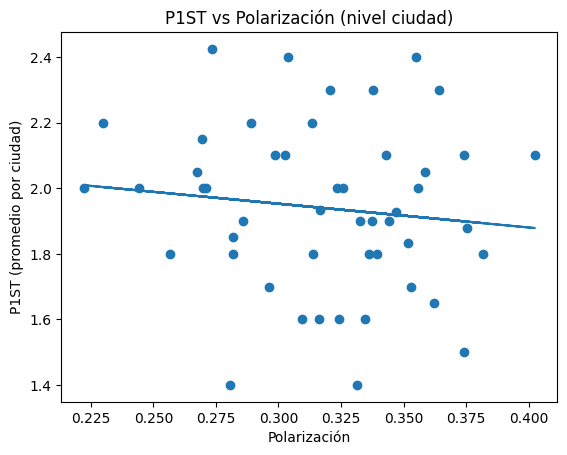

Número de ciudades: 49


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Colapsar a nivel ciudad (promedio de P1ST)
df_city = (
    df2[['CIUDAD','P1ST','polarizacion']]
    .dropna()
    .groupby('CIUDAD')
    .agg({
        'P1ST': 'mean',
        'polarizacion': 'mean'  # debería ser constante, pero por seguridad
    })
    .reset_index()
)

# 2. Scatter
x = df_city['polarizacion']
y = df_city['P1ST']

plt.figure()
plt.scatter(x, y)

# 3. Línea de tendencia
if len(df_city) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel('Polarización')
plt.ylabel('P1ST (promedio por ciudad)')
plt.title('P1ST vs Polarización (nivel ciudad)')

plt.show()

# 4. Chequeo
print("Número de ciudades:", len(df_city))

In [42]:
from scipy.stats import pearsonr

# filtrar por seguridad
df_corr = df_city[['polarizacion','P1ST']].dropna()

# coeficiente de Pearson y p-valor
r, pval = pearsonr(df_corr['polarizacion'], df_corr['P1ST'])

print("Coeficiente de Pearson (r):", r)
print("p-valor:", pval)
print("N:", len(df_corr))

Coeficiente de Pearson (r): -0.11802382304665529
p-valor: 0.41928194573531347
N: 49
